# Assessment | Statistical Evaluation Mini-Project

Work through the four tasks below using the **Auto MPG** dataset. Each task has its own section with scaffolding cells — add as many code and markdown cells as you need.

## Setup

Run the cell below to load the dataset and verify everything is working.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

SEED = 42
np.random.seed(SEED)

mpg = sns.load_dataset("mpg").dropna()

print(f"Rows: {len(mpg)}, Columns: {mpg.shape[1]}")
print(f"Origin groups: {mpg['origin'].unique().tolist()}")
mpg.head()

Rows: 392, Columns: 9
Origin groups: ['usa', 'japan', 'europe']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [16]:
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [20]:
mpg.nunique()

mpg             127
cylinders         5
displacement     81
horsepower       93
weight          346
acceleration     95
model_year       13
origin            3
name            301
dtype: int64

---
## Task 1 — Correlation Analysis

1. Choose at least three pairs of numeric variables and compute Pearson and Spearman correlations.
2. Test each for significance (report p-values).
3. Create a correlation heatmap and at least two scatter plots with regression lines.
4. Explain when Pearson vs. Spearman is more appropriate, using your results as examples.

In [17]:
# Correlation coefficients and p-values

pairs = [
    ("displacement", "weight"),
    ("horsepower", "acceleration"),
    ("acceleration", "mpg")
]

results = []

for x, y in pairs:
    # Pearson
    r, p_r = stats.pearsonr(mpg[x], mpg[y])
    
    # Spearman
    rho, p_rho = stats.spearmanr(mpg[x], mpg[y])
    
    results.append({
        "Pair": f"{x} vs {y}",
        "Pearson r": r,
        "Pearson p-value": p_r,
        "Spearman rho": rho,
        "Spearman p-value": p_rho
    })

corr_df = pd.DataFrame(results)
corr_df.round(3)

,Pair,Pearson r,Pearson p-value,Spearman rho,Spearman p-value
0,displacement vs weight,0.933,0.0,0.946,0.0
1,horsepower vs acceleration,-0.689,0.0,-0.658,0.0
2,acceleration vs mpg,0.423,0.0,0.442,0.0


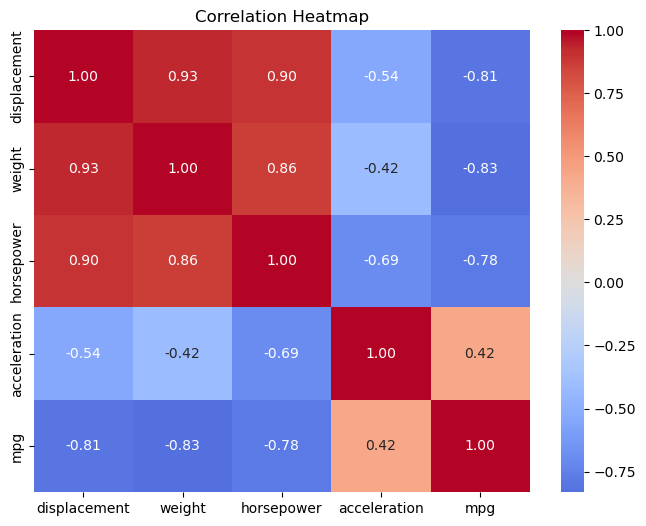

In [18]:
# Correlation heatmap

numeric_cols = ["displacement", "weight", "horsepower", "acceleration", "mpg"]

corr_matrix = mpg[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

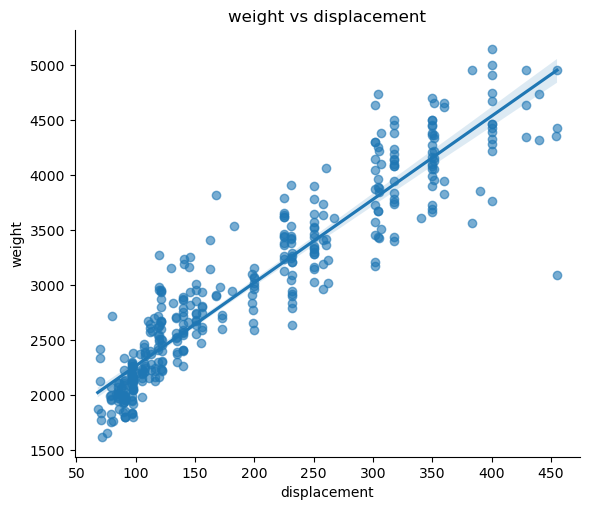

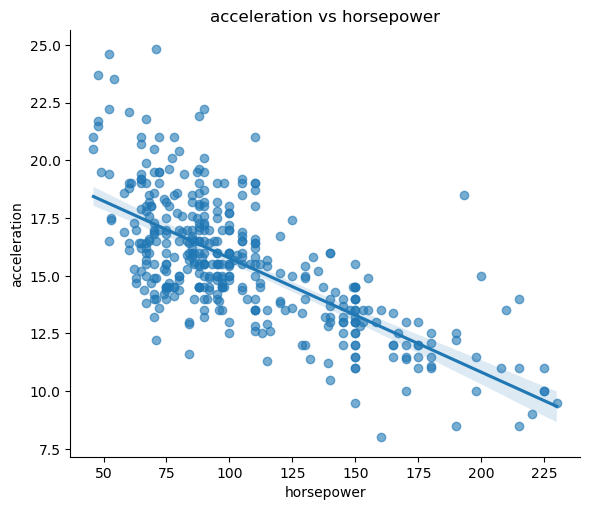

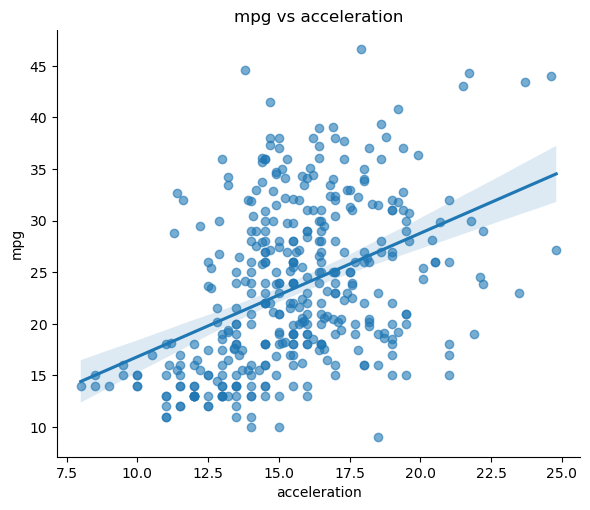

In [19]:
# Scatter plots with regression lines

for x, y in pairs:
    sns.lmplot(
        data=mpg,
        x=x,
        y=y,
        height=5,
        aspect=1.2,
        scatter_kws={"alpha": 0.6}
    )
    plt.title(f"{y} vs {x}")
    plt.show()

### Interpretation

*When is Pearson vs. Spearman more appropriate? Use your results as examples.*

In this analysis, Pearson and Spearman correlations are very similar for all selected pairs, which means that the relationships between the variables are mostly linear and do not contain strong outliers or non-linear patterns.

In general, Pearson correlation is more appropriate when the relationship between variables is linear, as it measures the strength of a straight-line relationship. For example, the strong correlation between displacement and weight as can be seen in the heatmap and scatter plot.

Spearman correlation is more appropriate when the relationship is monotonic but not necessarily linear, or when the data contains outliers. It works by comparing ranks rather than actual values, making it more sensitive to unusual observations.

In this dataset, since both methods give similar results, it indicates that the relationships are fairly well-behaved and approximately linear. If there were strong outliers or curved relationships, Spearman would differ from Pearson more significantly.

---
## Task 2 — Group Comparisons

1. Choose a numeric variable and visualize its distribution by origin (box/violin plot).
2. Check ANOVA assumptions: Shapiro-Wilk (normality) and Levene's test (equal variances).
3. Run one-way ANOVA — report F-statistic, p-value, and eta-squared.
4. If significant, run Tukey's HSD and state which groups differ.

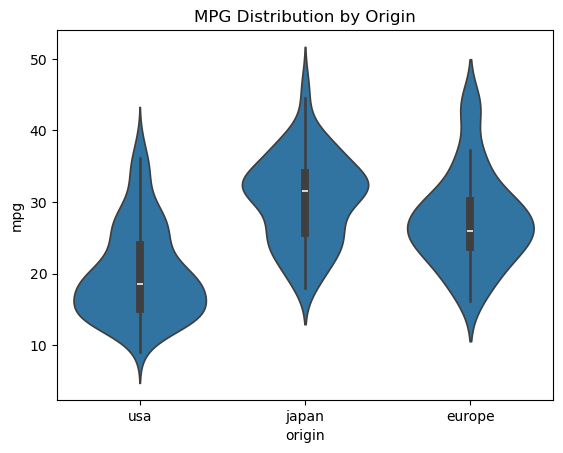

In [21]:
# Distribution visualization by origin

sns.violinplot(data=mpg, x="origin", y="mpg")
plt.title("MPG Distribution by Origin")
plt.show()


In [23]:
# Assumption checks: Shapiro-Wilk + Levene's test

for origin in mpg["origin"].unique():
    group = mpg[mpg["origin"] == origin]["mpg"]
    stat, p = stats.shapiro(group)
    print(f"{origin}: p-value = {p:.4f}")

    
groups = [mpg[mpg["origin"] == o]["mpg"] for o in mpg["origin"].unique()]

levene_stat, levene_p = stats.levene(*groups)

print("\nLevene p-value:", levene_p)

usa: p-value = 0.0000
japan: p-value = 0.2420
europe: p-value = 0.0054

Levene p-value: 0.9175294106303684


In [25]:
# One-way ANOVA

f_stat, p_value = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

# Total variance
grand_mean = mpg["mpg"].mean()

ss_total = ((mpg["mpg"] - grand_mean) ** 2).sum()

# Between-group variance
ss_between = sum(
    len(group) * (group.mean() - grand_mean) ** 2
    for group in groups
)

eta_squared = ss_between / ss_total

print("Eta-squared:", eta_squared)

F-statistic: 96.6015301631495
p-value: 8.673818448010683e-35
Eta-squared: 0.33184823902852273


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
europe  japan   2.8477 0.0203   0.3583   5.337   True
europe    usa  -7.5695    0.0  -9.6321 -5.5068   True
 japan    usa -10.4172    0.0 -12.3642 -8.4701   True
-----------------------------------------------------


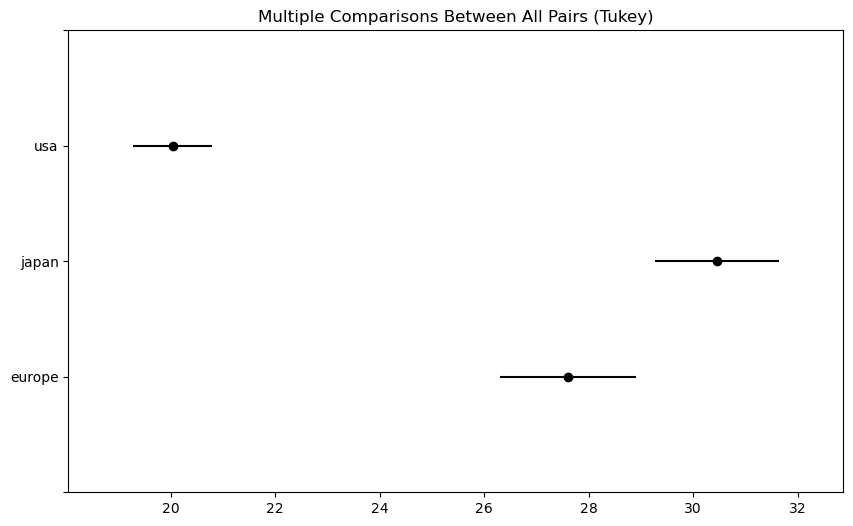

In [26]:
# Post-hoc test (Tukey's HSD)

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=mpg["mpg"],
    groups=mpg["origin"],
    alpha=0.05
)

print(tukey)
tukey.plot_simultaneous()
plt.show()


### Interpretation

*Which groups differ? What does the effect size tell you?*

The Tukey HSD results show that all pairs of origin groups differ significantly in their average mpg. Specifically, cars from Japan have higher mpg than those from Europe, and both Japan and Europe have significantly higher mpg than cars from the USA. The largest difference is between Japan and the USA, followed by Europe and the USA.

This means that fuel efficiency is not the same across regions — cars from different origins clearly perform differently, with Japanese cars being the most fuel-efficient on average and American cars the least.

The effect size (eta-squared ≈ 0.33) indicates a large effect. This means that about 33% of the variation in mpg can be explained by the car’s origin, which is a substantial proportion. In other words, origin is an important factor when it comes to fuel efficiency, not just a minor influence.

---
## Task 3 — Classification with Bootstrap Confidence Intervals

1. Prepare features (numeric columns) and target (`origin`). Train/test split (75/25, stratified).
2. Train at least two classifiers with default hyperparameters.
3. Print a classification report for each.
4. Write `bootstrap_metric()` and compute 95 % CIs for F1, precision, and recall.
5. Visualize the CIs and state which model you recommend.

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

numeric_cols = ["mpg", "cylinders", "displacement", "horsepower",
                "weight", "acceleration", "model_year"]

X = mpg[numeric_cols].values
y = mpg["origin"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Class distribution (test): {pd.Series(y_test).value_counts().to_dict()}")

Train: 294, Test: 98
Class distribution (test): {'usa': 61, 'japan': 20, 'europe': 17}


In [29]:
# Train classifiers and generate predictions

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


# Model 1: Logistic Regression
log_reg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=SEED)
)

# Model 2: KNN
knn = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier()
)

# Fit models
log_reg.fit(X_train, y_train)
knn.fit(X_train, y_train)

# Predictions
y_pred_log = log_reg.predict(X_test)
y_pred_knn = knn.predict(X_test)


In [30]:
# Classification reports

print("Logistic Regression")
print(classification_report(y_test, y_pred_log))

print("KNN")
print(classification_report(y_test, y_pred_knn))

Logistic Regression
              precision    recall  f1-score   support

      europe       0.89      0.47      0.62        17
       japan       0.61      0.70      0.65        20
         usa       0.86      0.93      0.90        61

    accuracy                           0.81        98
   macro avg       0.79      0.70      0.72        98
weighted avg       0.82      0.81      0.80        98

KNN
              precision    recall  f1-score   support

      europe       0.43      0.35      0.39        17
       japan       0.48      0.50      0.49        20
         usa       0.83      0.85      0.84        61

    accuracy                           0.69        98
   macro avg       0.58      0.57      0.57        98
weighted avg       0.69      0.69      0.69        98



In [31]:
def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=2000, seed=42):
    """Compute bootstrap 95% confidence interval for a classification metric.

    Returns
    -------
    point_estimate : float
    ci_lower : float
    ci_upper : float
    boot_scores : np.ndarray
    """
    rng = np.random.default_rng(seed)
    n = len(y_true)

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    point_estimate = metric_fn(y_true, y_pred)

    boot_scores = []

    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        y_true_boot = y_true[idx]
        y_pred_boot = y_pred[idx]

        score = metric_fn(y_true_boot, y_pred_boot)
        boot_scores.append(score)

    boot_scores = np.array(boot_scores)
    ci_lower = np.percentile(boot_scores, 2.5)
    ci_upper = np.percentile(boot_scores, 97.5)

    return point_estimate, ci_lower, ci_upper, boot_scores

In [33]:
# Apply bootstrap_metric for F1, precision, and recall (each model)

f1_weighted = lambda yt, yp: f1_score(yt, yp, average="weighted")
precision_weighted = lambda yt, yp: precision_score(yt, yp, average="weighted", zero_division=0)
recall_weighted = lambda yt, yp: recall_score(yt, yp, average="weighted", zero_division=0)

results = []

models = {
    "Logistic Regression": y_pred_log,
    "KNN": y_pred_knn
}

metrics = {
    "F1": f1_weighted,
    "Precision": precision_weighted,
    "Recall": recall_weighted
}

for model_name, y_pred in models.items():
    for metric_name, metric_fn in metrics.items():
        point, lower, upper, boot = bootstrap_metric(y_test, y_pred, metric_fn, n_boot=2000, seed=SEED)
        results.append({
            "Model": model_name,
            "Metric": metric_name,
            "Estimate": point,
            "CI Lower": lower,
            "CI Upper": upper
        })

ci_df = pd.DataFrame(results)
ci_df.round(3)

,Model,Metric,Estimate,CI Lower,CI Upper
0,Logistic Regression,F1,0.798,0.707,0.876
1,Logistic Regression,Precision,0.816,0.736,0.891
2,Logistic Regression,Recall,0.806,0.724,0.878
3,KNN,F1,0.689,0.592,0.781
4,KNN,Precision,0.685,0.587,0.787
5,KNN,Recall,0.694,0.602,0.786


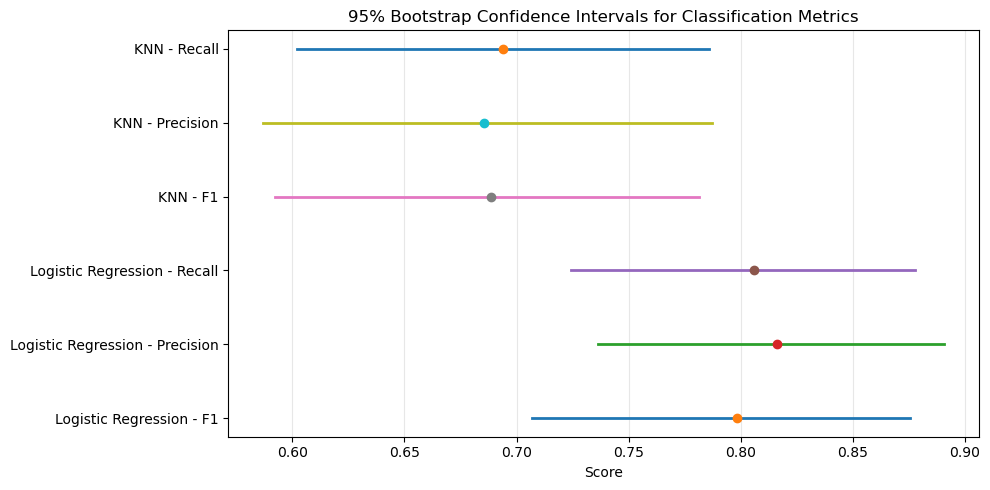

In [34]:
# Visualize bootstrap CIs (dot-and-whisker or grouped bar chart)

plt.figure(figsize=(10, 5))

for i, (_, row) in enumerate(ci_df.iterrows()):
    plt.plot([row["CI Lower"], row["CI Upper"]], [i, i], lw=2)
    plt.plot(row["Estimate"], i, "o")

plt.yticks(range(len(ci_df)), ci_df["Model"] + " - " + ci_df["Metric"])
plt.xlabel("Score")
plt.title("95% Bootstrap Confidence Intervals for Classification Metrics")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


### Recommendation

*Which model would you recommend? How confident are you based on the CIs?*

Two classifiers were trained to predict car origin: Logistic Regression and K-Nearest Neighbors (KNN).

Based on the bootstrap results, Logistic Regression consistently outperforms KNN across all evaluated metrics. The weighted F1 score for Logistic Regression is 0.798, compared to 0.689 for KNN. Similarly, Logistic Regression achieves higher precision (0.816 vs 0.685) and recall (0.806 vs 0.694).

The 95% confidence intervals further support this conclusion. For Logistic Regression, the F1 score ranges from approximately 0.707 to 0.876, while for KNN it ranges from 0.592 to 0.781. Although there is some overlap, the intervals for Logistic Regression are clearly shifted toward higher values across all metrics.

This indicates that Logistic Regression not only performs better on average, but also does so more consistently.

Overall, Logistic Regression is the recommended model for this task, as it provides stronger and more reliable performance in predicting car origin.

---
## Task 4 — Summary

Write a short summary (150–250 words) answering:

1. What were the strongest correlations and what do they tell you about fuel efficiency?
2. Do cars from different origins differ significantly? Which groups stand out?
3. Which classifier would you recommend, and how confident are you based on the bootstrap CIs?

### Your Summary

## Summary

The correlation analysis showed that some of the strongest relationships involve engine size (displacement), meaning that cars with larger engines tend to be heavier (obviously). Since heavier cars generally consume more fuel, this helps explain why fuel efficiency (mpg) decreases as engine size and weight increase. Similarly, horsepower shows a negative relationship with mpg, indicating that more powerful cars are typically less fuel-efficient.

The group comparison using ANOVA showed that cars from different origins differ significantly in terms of fuel efficiency. The results confirmed that Japanese cars have the highest average mpg, followed by European cars, while American cars have the lowest. Tukey’s HSD test showed that all pairs of groups differ significantly, with the largest gap observed between Japan and the USA. The effect size was relatively large, suggesting that origin plays an important role in determining fuel efficiency.

For classification, Logistic Regression performed better than KNN across all metrics. It achieved higher F1, precision, and recall scores, and its bootstrap confidence intervals were consistently higher. This indicates that the model is both more accurate and more stable. Based on these results, Logistic Regression is the recommended model, and the confidence intervals suggest a high level of reliability in its performance.